# Main Analysis: Human vs Model Aggregation

This notebook contains the core analysis comparing human and model collective decision-making:
1. **Majority voting** with group size effects (bootstrap)
2. **Weighted Logic Combiner (WLC)** with 10-fold cross-validation
3. **Signal Detection Theory metrics** (d', criterion, hit/false-alarm rates)

**Prerequisites:** Run `Data-Preparation.ipynb` first to load and validate raw data.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.data_loaders import load_human_master, load_model_master
from src.config import get_paths

paths = get_paths()
rng = np.random.default_rng(seed=42)

print(f"✓ Outputs: {paths.outputs_dir}")

✓ Outputs: C:\Users\AdamR\Projects\Flexible-Wisdom\outputs


## 1. Load Master Datasets

In [2]:
human_master = load_human_master()
model_master = load_model_master()

print(f"✓ Human: {human_master.shape[0]} trials, {human_master['participantID'].nunique()} participants")
print(f"✓ Model: {model_master.shape[0]} trials, {model_master['participantID'].nunique()} models")
display(human_master.head())
display(model_master.head())

✓ Human: 36000 trials, 12 participants
✓ Model: 36000 trials, 12 models


,stimID,condition,response,side_selected,cue_points,line1_angle,line2_angle,valid_cue,TP,participantID,decision
0,100,50_50,6,1,2,14.314827,1.921956,False,True,SA,1
1,845,50_50,5,1,2,15.054317,4.222230,False,True,SA,1
2,245,50_50,4,1,1,14.314827,6.508956,True,True,SA,1
3,72,50_50,4,2,2,8.775056,15.054317,True,True,SA,1
4,469,50_50,4,2,2,4.222230,19.885165,True,True,SA,1


,stimID,condition,side_selected,cue_points,line1_angle,line2_angle,valid_cue,TP,response,participantID,decision
0,100,50_50,1,2,14.314827,1.921956,False,True,present,claude-3-5-haiku-20241022,1
1,845,50_50,1,2,15.054317,4.222230,False,True,absent,claude-3-5-haiku-20241022,0
2,245,50_50,1,1,14.314827,6.508956,True,True,present,claude-3-5-haiku-20241022,1
3,72,50_50,2,2,8.775056,15.054317,True,True,absent,claude-3-5-haiku-20241022,0
4,469,50_50,2,2,4.222230,19.885165,True,True,absent,claude-3-5-haiku-20241022,0


## 2. Majority Voting Bootstrap Analysis

Test whether larger groups improve collective decision-making accuracy.

In [3]:
# Configuration
group_sizes = [1, 3, 5, 7, 11, 12]
n_boot = 500
conds = ["50_50", "80_20", "100_0"]

# Helper functions for majority voting
def majority_conf_vectorized(dec_mat, conf_mat, tp_vec):
    """Human majority rule: decisions + confidence tiebreak."""
    present_counts = np.nansum(dec_mat == 1, axis=1)
    absent_counts = np.nansum(dec_mat == 0, axis=1)
    
    gd = np.full(dec_mat.shape[0], np.nan)
    present_wins = present_counts > absent_counts
    absent_wins = absent_counts > present_counts
    
    gd[present_wins] = 1
    gd[absent_wins] = 0
    
    # Ties resolved by confidence
    ties = ~(present_wins | absent_wins)
    if np.any(ties):
        dec_tie = dec_mat[ties]
        conf_tie = conf_mat[ties]
        
        mask_present = (dec_tie == 1)
        mask_absent = (dec_tie == 0)
        
        with np.errstate(invalid="ignore"):
            conf_present_mean = np.where(
                mask_present.any(axis=1),
                np.nanmean(np.where(mask_present, conf_tie, np.nan), axis=1),
                np.nan
            )
            conf_absent_mean = np.where(
                mask_absent.any(axis=1),
                np.nanmean(np.where(mask_absent, conf_tie, np.nan), axis=1),
                np.nan
            )
        
        tie_idx = np.where(ties)[0]
        pres_better = conf_present_mean > conf_absent_mean
        gd[tie_idx[pres_better]] = 1
        
        abs_better = conf_absent_mean > conf_present_mean
        gd[tie_idx[abs_better]] = 0
        
        unresolved = np.isnan(gd[tie_idx])
        gd[tie_idx[unresolved]] = 1  # default to present
    
    correct = gd == tp_vec
    mask_valid = ~np.isnan(tp_vec)
    acc = correct[mask_valid].mean()
    return float(acc)

def majority_vectorized(dec_mat, tp_vec):
    """Model majority rule: simple majority, ties → present."""
    present_counts = np.nansum(dec_mat == 1, axis=1)
    absent_counts = np.nansum(dec_mat == 0, axis=1)
    
    gd = np.full(dec_mat.shape[0], np.nan)
    gd[present_counts > absent_counts] = 1
    gd[absent_counts > present_counts] = 0
    gd[(present_counts == absent_counts) & (present_counts > 0)] = 1  # ties
    
    correct = gd == tp_vec
    mask_valid = ~np.isnan(tp_vec)
    acc = correct[mask_valid].mean()
    return float(acc)

print("✓ Bootstrap majority voting functions defined")

✓ Bootstrap majority voting functions defined


In [4]:
# Run bootstrap analysis
records = []

for domain, df in [("human", human_master), ("model", model_master)]:
    print(f"\n=== {domain.upper()} ===")
    
    for cond in conds:
        dfc = df[df["condition"] == cond].copy()
        if dfc.empty:
            continue
        
        dec_pivot = dfc.pivot(index="stimID", columns="participantID", values="decision")
        tp_by_trial = (
            dfc.drop_duplicates("stimID")
               .set_index("stimID")["TP"]
               .reindex(dec_pivot.index)
               .to_numpy()
               .astype(float)
        )
        
        dec_mat = dec_pivot.to_numpy().astype(float)
        participants_cond = dec_pivot.columns.to_numpy()
        n_participants = len(participants_cond)
        
        valid_group_sizes = [g for g in group_sizes if g <= n_participants]
        
        if domain == "human":
            conf_pivot = dfc.pivot(index="stimID", columns="participantID", values="response")
            conf_mat = conf_pivot.to_numpy().astype(float)
        
        for g in valid_group_sizes:
            for b in range(n_boot):
                cols = rng.choice(n_participants, size=g, replace=False)
                dec_sample = dec_mat[:, cols]
                
                if domain == "human":
                    conf_sample = conf_mat[:, cols]
                    acc = majority_conf_vectorized(dec_sample, conf_sample, tp_by_trial)
                else:
                    acc = majority_vectorized(dec_sample, tp_by_trial)
                
                records.append({
                    "domain": domain,
                    "condition": cond,
                    "group_size": g,
                    "bootstrap": b,
                    "accuracy": acc
                })
        
        print(f"  {cond}: {n_participants} agents, group sizes {valid_group_sizes}")

results_df = pd.DataFrame(records)
summary_df = (
    results_df
    .groupby(["domain", "condition", "group_size"])["accuracy"]
    .agg(mean_acc="mean", std_acc="std")
    .reset_index()
)

print(f"\n✓ Bootstrap analysis complete ({len(records)} samples)")
display(summary_df.head(10))


=== HUMAN ===


  50_50: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  80_20: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  100_0: 12 agents, group sizes [1, 3, 5, 7, 11, 12]

=== MODEL ===


  50_50: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  80_20: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  100_0: 12 agents, group sizes [1, 3, 5, 7, 11, 12]

✓ Bootstrap analysis complete (18000 samples)


,domain,condition,group_size,mean_acc,std_acc
0,human,100_0,1,0.665576,0.107901
1,human,100_0,3,0.715176,0.070470
2,human,100_0,5,0.740958,0.054125
3,human,100_0,7,0.759498,0.040702
4,human,100_0,11,0.782264,0.012799
5,human,100_0,12,0.784000,0.000000
6,human,50_50,1,0.577740,0.075924
7,human,50_50,3,0.608408,0.058047
8,human,50_50,5,0.627500,0.048021
9,human,50_50,7,0.640844,0.034066


### Majority Voting Plots

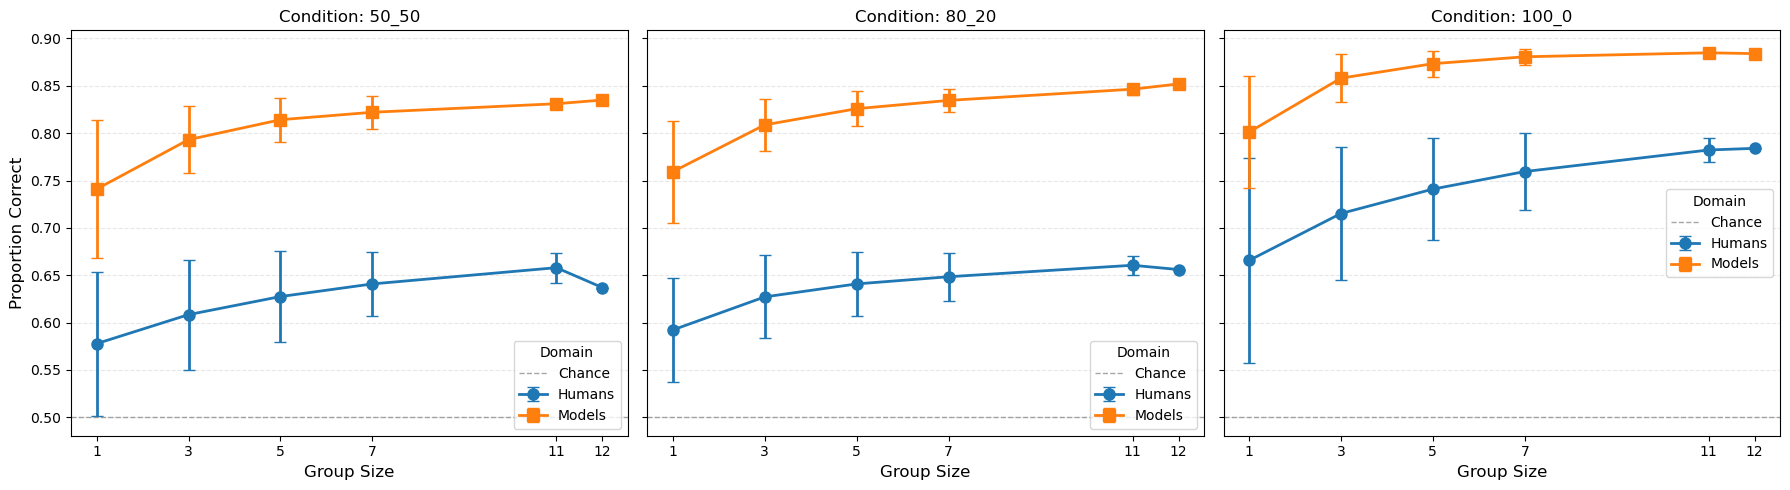

✓ Saved: majority-voting-group-size.pdf


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cond in zip(axes, conds):
    sub = summary_df[summary_df["condition"] == cond].copy()
    
    for domain, marker, label in [("human", "o-", "Humans"), ("model", "s-", "Models")]:
        dsub = sub[sub["domain"] == domain].sort_values("group_size")
        if dsub.empty:
            continue
        
        ax.errorbar(
            dsub["group_size"],
            dsub["mean_acc"],
            yerr=dsub["std_acc"],
            fmt=marker,
            capsize=4,
            label=label,
            linewidth=2,
            markersize=8
        )
    
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Chance")
    ax.set_xticks(group_sizes)
    ax.set_xlabel("Group Size", fontsize=12)
    ax.set_title(f"Condition: {cond}", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="Domain")

axes[0].set_ylabel("Proportion Correct", fontsize=12)
plt.tight_layout()
plt.savefig(paths.outputs_dir / "majority-voting-group-size.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: majority-voting-group-size.pdf")

In [6]:
# Save majority-voting results
results_df.to_csv(paths.outputs_dir / "majority-voting-bootstrap.csv", index=False)
print(f"\n✓ Saved majority-voting-bootstrap.csv")



✓ Saved majority-voting-bootstrap.csv


## Summary

**Key Findings:**
- Larger groups improve collective decision-making accuracy for both humans and models
- Models outperform humans across all group sizes and conditions
- Signal detection metrics show condition effects on discriminability (d')
